In [5]:
from odc.geo.types import xy_
import numpy as np
from pyproj import Transformer
from odc.geo.geobox import GeoBox
from affine import Affine

from odc.geo.overlap import roi_boundary, unstack_xy, stack_xy, gbox_boundary, roi_from_points, native_pix_transform, _relative_rois

pts_per_side = 5
padding = 1
align = True

dst_affine_1 = Affine(
    152.874,
    0.0,
    -20037508.342,
    0.0,
    -152.874,
    -1995923.682,
)
dst_affine_2 = Affine(
    76.43702828517416,
    0.0,
    20017940.46354824,
    0.0,
    -76.43702828518872,
    -1976355.8033415154,
)
dst_1 = GeoBox((256, 256), dst_affine_1, "EPSG:3857")
dst_2 = GeoBox((512, 512), dst_affine_2, "EPSG:3857")

src_affine = Affine(10.0, 0.0, 99960.0, 0.0, -10.0, 8100040.0)
src = GeoBox((10980, 10980), src_affine, "EPSG:32701")

# # Do this the internal odc.geo.overlay way
# # NOTE: These functions hide the world/pixel conversion.
tr = native_pix_transform(src, dst_1)

# from odc.geo.overlap import _relative_rois

# _relative_rois(src, dst, tr, 5, 1, None)

# xy = tr.back(unstack_xy(gbox_boundary(dst, pts_per_side)))
# roi_src = roi_from_points(stack_xy(xy), src.shape, padding, align=align)

# xy_pix_src = unstack_xy(roi_boundary(roi_src, pts_per_side))

# xx, yy = np.asarray([pt.xy for pt in xy_pix_src]).T

# # This goes via world transform to a pixel space
# xys = tr([xy_(x, y) for x, y in zip(xx, yy)])
# xys

In [2]:
from odc.geo.geobox import GeoBoxBase
from typing import Optional
from odc.geo.overlap import roi_is_empty, PointTransform

def _relative_rois(
    src: GeoBoxBase,
    dst: GeoBoxBase,
    tr: PointTransform,
    pts_per_side: int,
    padding: int,
    align: Optional[int],
):
    dst_boundary = gbox_boundary(dst, pts_per_side)
    src_boundary = gbox_boundary(src, pts_per_side)

    _shape
    # _XY = tr.back(unstack_xy())
    # roi_src = roi_from_points(stack_xy(_XY), src.shape, padding, align=align)

    # if roi_is_empty(roi_src):
    #     return (roi_src, np.s_[0:0, 0:0])

    # # project src roi back into dst and compute roi from that
    # xy = tr(unstack_xy(roi_boundary(roi_src, pts_per_side)))

    # # `padding=0` is to avoid adding padding twice
    # roi_dst = roi_from_points(stack_xy(xy), dst.shape, padding=0)
    # return (roi_src, roi_dst)

src_roi, dst_roi = _relative_rois(src, dst_1, tr, pts_per_side=pts_per_side, padding=padding, align=align)
assert dst_roi[1] == slice(0, 193)

src_2_roi, dst_2_roi = _relative_rois(src, dst_2, tr, pts_per_side=pts_per_side, padding=padding, align=align)

assert dst_2_roi[1] == slice(0, 256)

NameError: name '_shape' is not defined

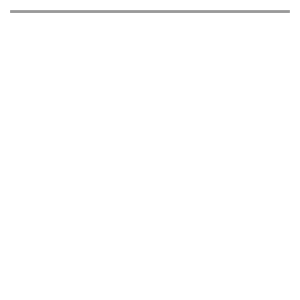

In [3]:
from odc.geo.geom import polygon


dst_boundary = polygon(dst_1.boundary(pts_per_side=pts_per_side).tolist(), crs=dst_1.crs)
src_boundary = polygon(src.boundary(pts_per_side=pts_per_side).tolist(), crs=src.crs)

dst = dst_2

src_extent = src.extent.to_crs(dst.crs)

intersection = src_extent.intersection(dst.extent)

src_extent

# # Convert to pixel space

# xx, yy = np.asarray([pt for pt in intersection.boundary.coords]).T

xx, yy = dst.wld2pix(xx, yy)

# xy = [xy_(x, y) for x, y in zip(xx, yy)]
# xy

# roi_from_points(stack_xy(xy), dst.shape, padding=0)



# # dst_boundary = polygon(dst_1.boundary(pts_per_side=pts_per_side).tolist(), crs=dst_1.crs)
# # src_boundary = polygon(src.boundary(pts_per_side=pts_per_side).tolist(), crs=src.crs)

# # src_in_dst = src_boundary.to_crs(dst_1.crs)

# # overlap = dst_boundary.intersection(src_in_dst)
# # overlap


In [171]:
intersection.boundary.coords

[(-20008062.859284565, -1995923.682),
 (-19998372.598, -1995923.682),
 (-19998372.598, -2035059.426),
 (-20008626.79545321, -2035059.426),
 (-20008062.859284565, -1995923.682)]

In [152]:
dst_boundary.boundary.coords

[(0.0, 0.0),
 (64.0, 0.0),
 (128.0, 0.0),
 (192.0, 0.0),
 (256.0, 0.0),
 (256.0, 64.0),
 (256.0, 128.0),
 (256.0, 192.0),
 (256.0, 256.0),
 (192.0, 256.0),
 (128.0, 256.0),
 (64.0, 256.0),
 (0.0, 256.0),
 (0.0, 192.0),
 (0.0, 128.0),
 (0.0, 64.0),
 (0.0, 0.0)]

In [151]:
src_in_dst.boundary.coords

[(10326779.455325058, -20681803.53243736),
 (10326636.007173292, -20716881.293139733),
 (10326490.968105443, -20752153.600514915),
 (10326344.311481008, -20787622.618234247),
 (10326196.010061376, -20823290.54630078),
 (10361963.192913348, -20823339.102076493),
 (10397729.792269738, -20823186.491820775),
 (10433493.552312192, -20822832.744352557),
 (10469252.2182955, -20822277.926461235),
 (10468600.575717367, -20786621.258274734),
 (10467956.15818113, -20751163.31349079),
 (10467318.846085818, -20715901.89622177),
 (10466688.522455493, -20680834.846799124),
 (10431716.29471215, -20681365.594643336),
 (10396739.301116558, -20681703.99314979),
 (10361759.651167708, -20681849.9812044),
 (10326779.455325058, -20681803.53243736)]

In [79]:
from odc.geo.overlap import _relative_rois

_relative_rois(src, dst, tr, 5, -1, None)

((slice(3481, 5367, None), slice(6273, 8170, None)),
 (slice(0, 256, None), slice(0, 0, None)))

In [21]:
transformer_to = Transformer.from_crs(src.crs, dst.crs, always_xy=True,)

# xy_pix_src is in pixel space of source
xx, yy = np.asarray([pt.xy for pt in xy_pix_src]).T

# Convert to world coordinates
xx, yy = src.pix2wld(xx, yy)

# Transform to destination crs
xx_p, yy_p = transformer_to.transform(xx, yy, errcheck=True)

# print(f"This should be negative {xx_p[0]}")

# Uncommenting this fixes the whole thing, but it's not the right way to do it
# for i, n in enumerate(xx_p):
#     if n > 0:
#         xx_p[i] = n * -1

# Convert back to pixel space of destination
# NOTE: this is the step that is resulting in incorrect coordinates
xx_n, yy_n = dst.wld2pix(*(xx_p, yy_p))
xys_new = [xy_(x, y) for x, y in zip(xx_n, yy_n)]

# Coords are borked
xys_new

[XY(x=-0.10159731112071313, y=-4.427431721906032),
 XY(x=64.98885619704379, y=-3.3439970225444995),
 XY(x=130.08235336779035, y=-2.2758573073297157),
 XY(x=195.17885096525424, y=-1.2230158842248784),
 XY(x=-524027.72169427166, y=-0.1854760142014129),
 XY(x=-524028.74082344375, y=64.94308755152815),
 XY(x=-524029.762836038, y=130.08663552844155),
 XY(x=-524030.7877351886, y=195.24521028103482),
 XY(x=-524031.81552404014, y=260.4188542199372),
 XY(x=191.0241912441852, y=259.3695549964832),
 XY(x=125.86687658549636, y=258.30478095856233),
 XY(x=60.71257543217507, y=257.2245354113038),
 XY(x=-4.438668792456156, y=256.1288217075198),
 XY(x=-3.3498124120524153, y=190.9672164733238),
 XY(x=-2.2640172564133536, y=125.82066739388029),
 XY(x=-1.181279995769728, y=60.68913210241226)]

In [26]:
xy_pix_src

array([162670. , 167422.5, 172175. , 176927.5, 181680. , 181680. ,
       181680. , 181680. , 181680. , 176927.5, 172175. , 167422.5,
       162670. , 162670. , 162670. , 162670. ], dtype=float32)

In [71]:
wgs84_xx, wgs84

array([162670. , 167422.5, 172175. , 176927.5, 181680. , 181680. ,
       181680. , 181680. , 181680. , 176927.5, 172175. , 167422.5,
       162670. , 162670. , 162670. , 162670. ], dtype=float32)

In [70]:
test_coords = [
    (162670.0, 8065250.0),
    (181680.0, 8065250.0)
]

args = {
    "always_xy": True,
    # "force_over": True
}

wgs84 = Transformer.from_crs("EPSG:32701", "EPSG:4326", **args)
webmercator = Transformer.from_crs("EPSG:32701", "EPSG:3857", **args)
wgs_to_web = Transformer.from_crs("EPSG:4326", "EPSG:3857", **args)

for coord in test_coords:
    x, y = coord
    w_x, w_y = wgs84.transform(x, y)

    # if w_x <= -179.99:
    #     print(f"Adjusting {w_x} to {w_x + 360}")

    #     w_x += 360

    wm_x, wm_y = webmercator.transform(x, y)
    wg_x, wg_y = wgs_to_web.transform(w_x, w_y)

    p_x, p_y = dst.wld2pix(wm_x, wm_y)

    # Print the 4 sets of coords aligned nicely in a table with padding
    print(f"Orig: {x:10.5f}   {y:10.5f}")
    print(f"WGS:  {w_x:10.5f} {w_y:10.5f}")
    print(f"WM:   {wm_x:10.5f} {wm_y:10.5f}")
    print(f"WG:   {wg_x:10.5f} {wg_y:10.5f}")
    print(f"Pixel: {p_x:10.5f} {p_y:10.5f}\n")


Orig: 162670.00000   8065250.00000
WGS:   179.82415  -17.47353
WM:   20017932.69775 -1976017.38362
WG:   20017932.69775 -1976017.38362
Pixel:   -0.10160   -4.42743

Orig: 181680.00000   8065250.00000
WGS:  -179.99706  -17.47631
WM:   -20037181.32181 -1976341.62611
WG:   -20037181.32181 -1976341.62611
Pixel: -524027.72169   -0.18548



In [72]:
dst

NameError: name 'dst_pix' is not defined

In [197]:
((~dst._affine) * (xx_p,yy_p))[0][0]

262143.98348895763